# Business Problem

Customers send back a substantial part of the products that they purchase online. Return shipping is expensive for online platforms and return orders are said to reach 50% for certain industries and products. Nevertheless, free or inexpensive return shipping has become a customer expectation and de-facto standard in the fierce online competition on clothing, but shops have indirect ways to influence customer purchase behavior. For purchases where return seems likely, a shop could, for example, restrict payment options or display additional marketing communication.

**The goal of this project is to identify purchases that are likely to be returned so that the retailer can take appropriate preventive or operational actions.**

# Importing necessary libaries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Data Loading

In [7]:
df=pd.read_csv("Walmart.csv")

# Data Preview

In [9]:
df.head()

,order_item_id,order_date,delivery_date,item_id,item_size,item_color,brand_id,item_price,user_id,user_title,user_dob,user_state,user_reg_date,return
0,1,22-06-2016,27-06-2016,643,38,navy,30,49.9,30822,Mrs,17-04-1969,1013,23-06-2016,0
1,10,22-06-2016,27-06-2016,195,xxl,grey,46,19.9,30823,Mrs,22-04-1970,1001,15-03-2015,1
2,11,22-06-2016,05-07-2016,25,xxl,grey,5,79.9,30823,Mrs,22-04-1970,1001,15-03-2015,0
3,32,23-06-2016,26-06-2016,173,m,brown,20,19.9,17234,Mrs,09-01-1960,1013,17-02-2015,0
4,43,23-06-2016,26-06-2016,394,40,black,44,90.0,30827,Mrs,NaN,1006,09-02-2016,1


In [10]:
df.shape

(79945, 14)

In [11]:
df.dtypes

order_item_id      int64
order_date        object
delivery_date     object
item_id            int64
item_size         object
item_color        object
brand_id           int64
item_price       float64
user_id            int64
user_title        object
user_dob          object
user_state         int64
user_reg_date     object
return             int64
dtype: object

In [12]:
df.describe()

,order_item_id,item_id,brand_id,item_price,user_id,user_state,return
count,79945.000000,79945.000000,79945.000000,79945.000000,79945.000000,79945.000000,79945.000000
mean,50056.599925,924.281231,30.100819,65.088521,27185.708500,1007.268485,0.458590
std,28872.601957,702.577022,28.157290,47.729105,14063.256304,4.281872,0.498285
min,1.000000,1.000000,1.000000,0.000000,9.000000,1001.000000,0.000000
25%,25133.000000,214.000000,5.000000,29.900000,14943.000000,1002.000000,0.000000
50%,49985.000000,812.000000,25.000000,49.900000,31189.000000,1008.000000,0.000000
75%,75118.000000,1582.000000,44.000000,79.900000,38931.000000,1010.000000,1.000000
max,100000.000000,2241.000000,138.000000,999.000000,48241.000000,1016.000000,1.000000


In [13]:
df.isnull().sum()

order_item_id       0
order_date          0
delivery_date    7436
item_id             0
item_size           0
item_color          0
brand_id            0
item_price          0
user_id             0
user_title          0
user_dob         6989
user_state          0
user_reg_date       0
return              0
dtype: int64

In [14]:
df.duplicated().sum()

0

In [15]:
(df["return"].value_counts(normalize=True)*100).round(2)

return
0    54.14
1    45.86
Name: proportion, dtype: float64

# Data cleaning

In [17]:
date_cols = [
    "order_date",
    "delivery_date",
    "user_dob",
    "user_reg_date"
]

for col in date_cols:
    df[col] = pd.to_datetime(
        df[col],
        dayfirst=True,
        errors="coerce"
    )

In [18]:
df.dtypes

order_item_id             int64
order_date       datetime64[ns]
delivery_date    datetime64[ns]
item_id                   int64
item_size                object
item_color               object
brand_id                  int64
item_price              float64
user_id                   int64
user_title               object
user_dob         datetime64[ns]
user_state                int64
user_reg_date    datetime64[ns]
return                    int64
dtype: object

In [19]:
df[df["item_color"] == "?"].shape[0]

49

In [20]:
df["item_color"] = df["item_color"].replace("?", np.nan)

In [21]:
df["item_color"].isnull().sum()

49

# EDA

In [23]:
num_cols = df.select_dtypes(include=["number"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Numerical Columns: ['order_item_id', 'item_id', 'brand_id', 'item_price', 'user_id', 'user_state', 'return']
Categorical Columns: ['item_size', 'item_color', 'user_title']


In [24]:
df[df["delivery_date"].isnull()]

,order_item_id,order_date,delivery_date,item_id,item_size,item_color,brand_id,item_price,user_id,user_title,user_dob,user_state,user_reg_date,return
14,163,2016-06-23,NaT,27,6+,black,19,39.90,22533,Mrs,1950-08-24,1015,2015-08-08,0
28,278,2016-06-23,NaT,895,48,ocher,39,39.95,20510,Mrs,1961-08-09,1008,2015-02-21,0
30,286,2016-06-23,NaT,896,l,red,33,9.90,30867,Mrs,1968-06-05,1010,2016-01-31,0
32,307,2016-06-23,NaT,68,m,purple,3,19.90,30870,Mrs,1958-11-20,1016,2016-06-24,0
62,556,2016-06-22,NaT,173,l,brown,20,19.90,18912,Mrs,1965-06-10,1002,2015-02-17,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79829,98745,2016-09-09,NaT,2071,unsized,red,48,16.95,47990,Mrs,1985-06-08,1001,2016-09-10,0
79852,98943,2016-09-10,NaT,169,45,brown,18,89.90,48033,Mrs,1991-11-07,1006,2016-09-11,0
79858,99012,2016-09-09,NaT,369,m,brown,5,39.90,25573,Mrs,1964-04-29,1010,2015-02-17,0
79861,99025,2016-09-10,NaT,100,39,red,43,69.90,18602,Mrs,1962-06-15,1001,2016-05-13,0


In [25]:
df[df["delivery_date"].isnull()]["return"].value_counts()

return
0    7436
Name: count, dtype: int64

In [26]:
df[df["user_dob"].isnull()].head()

,order_item_id,order_date,delivery_date,item_id,item_size,item_color,brand_id,item_price,user_id,user_title,user_dob,user_state,user_reg_date,return
4,43,2016-06-23,2016-06-26,394,40,black,44,90.0,30827,Mrs,NaT,1006,2016-02-09,1
12,135,2016-06-23,2016-06-27,34,41,red,23,89.9,30491,Mrs,NaT,1009,2016-06-22,1
26,258,2016-06-23,2016-06-26,896,xl,red,33,9.9,1687,Mrs,NaT,1010,2016-04-03,0
41,405,2016-06-23,2016-06-26,66,unsized,beige,32,9.9,19757,Mrs,NaT,1006,2016-05-20,0
50,488,2016-06-23,2016-06-27,67,xl,blue,20,49.9,30906,Mrs,NaT,1007,2016-06-24,1


In [27]:
df[df["user_dob"].isnull()]["return"].value_counts()

return
0    3815
1    3174
Name: count, dtype: int64

In [28]:
df['item_price'].describe()

count    79945.000000
mean        65.088521
std         47.729105
min          0.000000
25%         29.900000
50%         49.900000
75%         79.900000
max        999.000000
Name: item_price, dtype: float64

In [29]:
df[df['item_price']==0][['item_id','item_size','item_color','brand_id','item_price','return']]

,item_id,item_size,item_color,brand_id,item_price,return
137,157,unsized,purple,32,0.0,0
272,157,unsized,purple,32,0.0,0
283,157,unsized,purple,32,0.0,0
309,62,unsized,white,5,0.0,0
437,157,unsized,purple,32,0.0,0
...,...,...,...,...,...,...
77792,2121,unsized,orange,126,0.0,0
78505,1472,unsized,brown,60,0.0,1
78558,1472,unsized,brown,60,0.0,1
78770,1951,unsized,silver,126,0.0,0


In [30]:
df[df['item_price']==0].shape[0]

312

In [31]:
df[df["item_price"] == 0]["return"].value_counts()

return
0    279
1     33
Name: count, dtype: int64

In [32]:
df['item_size'].unique()

array(['38', 'xxl', 'm', '40', '42', 'l', 'xl', '41', '7', '6+', '18',
       '44', '19', '48', 'unsized', '36', '6', '4', '39', '45', '37',
       '7+', 's', '8', '9+', '50', '5+', '46', '9', '35', '21', '10',
       '43', '11+', '8+', '24', '20', '128', '11', '39+', '38+', '5',
       '12', '31', '140', '41+', '116', '4+', '40+', '56', '26', '47',
       '52', '32', '28', '10+', '27', '22', '152', '30', '1', '104', '33',
       'xs', '37+', '46+', '34', 'xxxl', '29', '13', '42+', '23', '3632',
       '25', '3+', '54', '36+', '44+', '3832', '3332', '4032', '3432',
       '43+', '100', '2', '176', '3', '164', '45+', '90', '105', '58',
       '4034', '3834', '80', '2+', '3132', '14', '12+', '49', '84',
       '3634'], dtype=object)

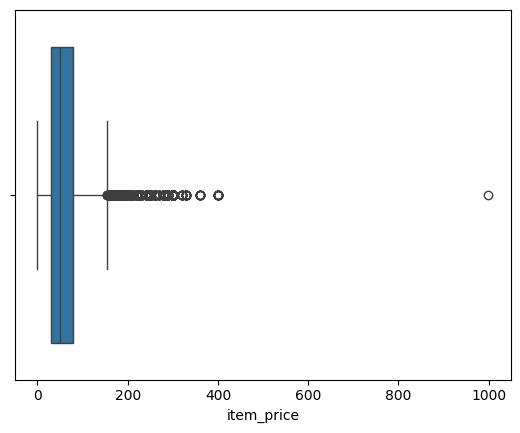

In [33]:
sns.boxplot(x=df["item_price"])
plt.show()

In [34]:
Q1 = df["item_price"].quantile(0.25)
Q3 = df["item_price"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Q1:",Q1)
print("Q3:",Q3)
print("IQR:",IQR)
print("Lower:",lower)
print("Upper:",upper)

Q1: 29.9
Q3: 79.9
IQR: 50.00000000000001
Lower: -45.100000000000016
Upper: 154.90000000000003


In [35]:
outliers = df[
    (df["item_price"] < lower) |
    (df["item_price"] > upper)
]

outliers.shape

(4975, 14)

In [36]:
outliers.sort_values("item_price", ascending=False).head()

,order_item_id,order_date,delivery_date,item_id,item_size,item_color,brand_id,item_price,user_id,user_title,user_dob,user_state,user_reg_date,return
66573,65020,2016-08-11,1994-12-31,2120,unsized,black,133,999.00,4323,Mrs,1971-12-24,1001,2016-04-08,1
76450,64679,2016-08-11,2016-08-14,1930,xxl,black,35,399.95,14794,Mrs,1972-10-21,1001,2015-02-17,1
8631,86611,2016-08-29,2016-08-31,1930,xxl,black,35,399.95,42372,Mrs,1976-03-08,1008,2016-08-14,1
76177,61960,2016-08-09,2016-08-13,1930,s,black,35,399.95,41480,Mr,NaT,1002,2016-08-10,0
9739,97742,2016-09-09,2016-09-11,1930,s,dark navy,35,399.95,9756,Mrs,1963-01-19,1010,2015-02-17,1


In [37]:
outliers[outliers['item_price']>upper]['return'].value_counts()

return
1    2956
0    2019
Name: count, dtype: int64

<Axes: xlabel='return', ylabel='count'>

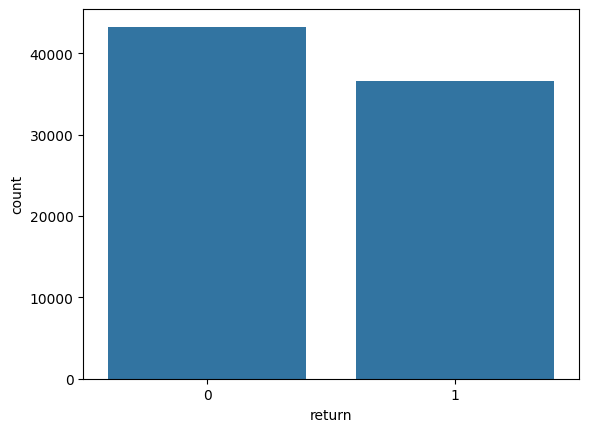

In [38]:
sns.countplot(x=df['return'])

<Axes: xlabel='user_title', ylabel='count'>

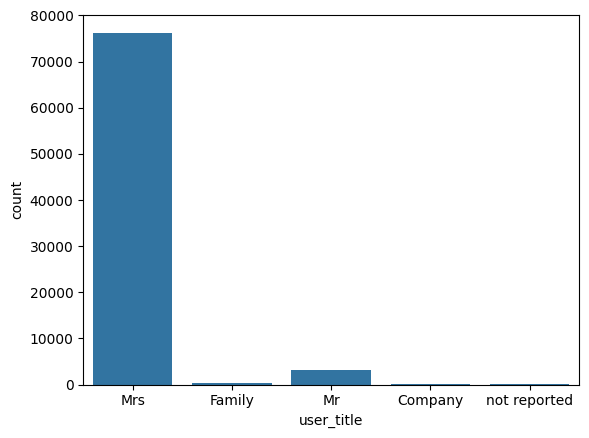

In [39]:
sns.countplot(x=df['user_title'])

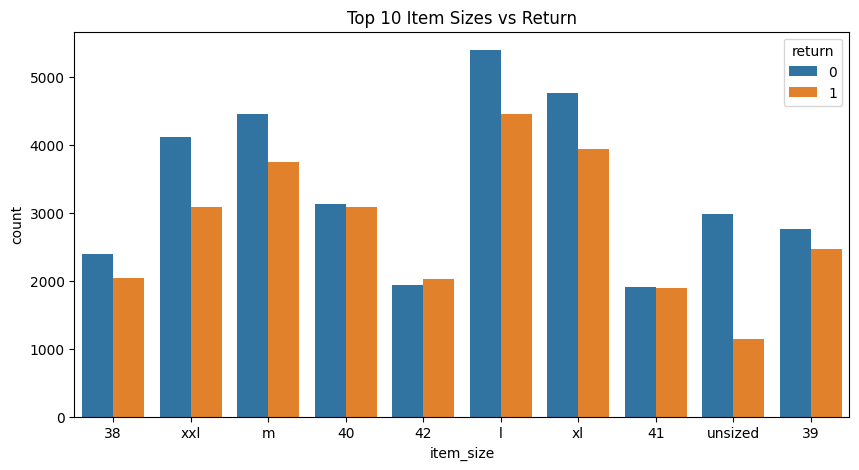

In [40]:
top10 = df["item_size"].value_counts().head(10).index

plt.figure(figsize=(10,5))
sns.countplot(
    data=df[df["item_size"].isin(top10)],
    x="item_size",
    hue="return"
)
plt.title("Top 10 Item Sizes vs Return")
plt.show()

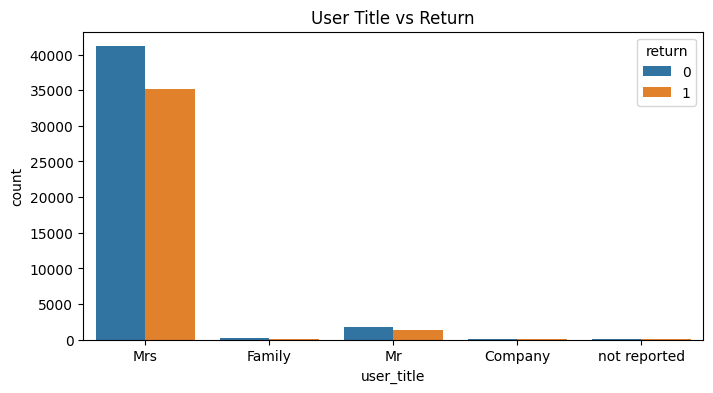

In [41]:
plt.figure(figsize=(8,4))
sns.countplot(
    data=df,
    x="user_title",
    hue="return"
)
plt.title("User Title vs Return")
plt.show()

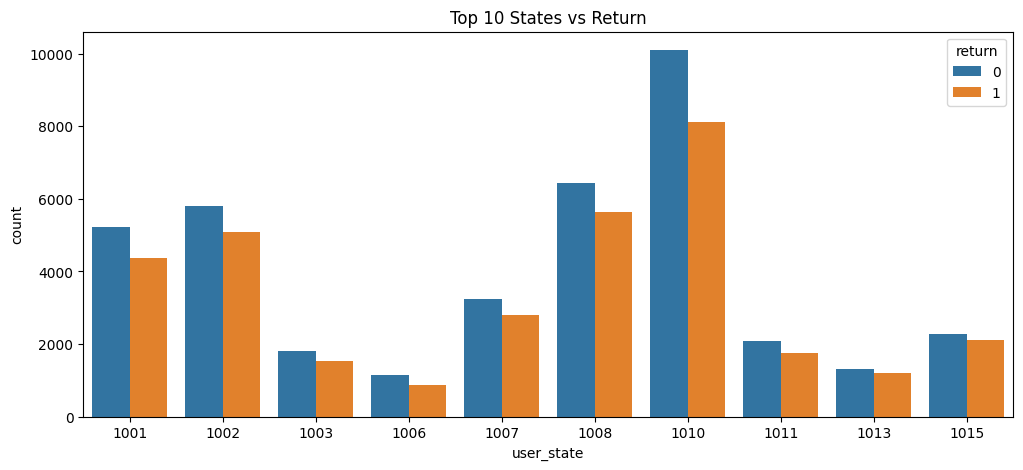

In [42]:
top10 = df["user_state"].value_counts().head(10).index

plt.figure(figsize=(12,5))
sns.countplot(
    data=df[df["user_state"].isin(top10)],
    x="user_state",
    hue="return"
)
plt.title("Top 10 States vs Return")
plt.show()

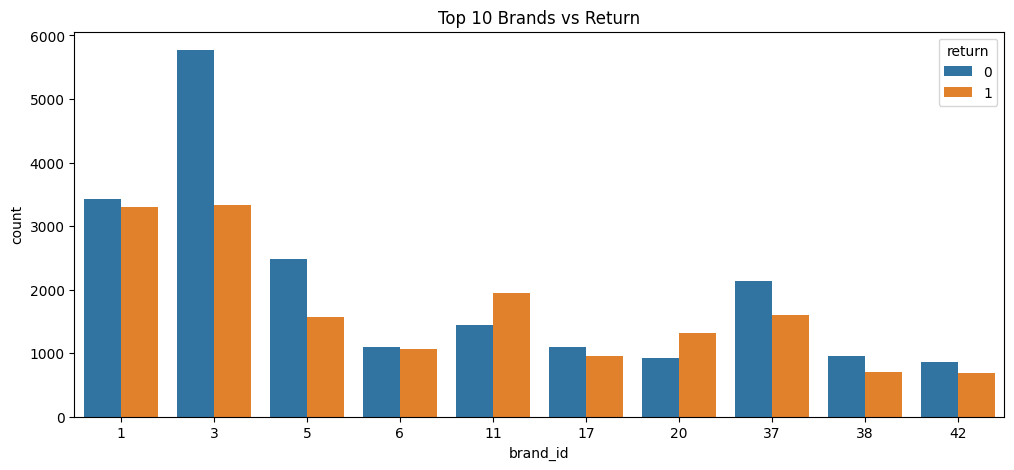

In [43]:
top10 = df["brand_id"].value_counts().head(10).index

plt.figure(figsize=(12,5))
sns.countplot(
    data=df[df["brand_id"].isin(top10)],
    x="brand_id",
    hue="return"
)
plt.title("Top 10 Brands vs Return")
plt.show()

# Feature Engineering

In [45]:
model_df = df.copy()

In [46]:
model_df["size_type"] = np.nan
model_df["size_value"] = np.nan
model_df["waist_size"] = np.nan
model_df["inseam_size"] = np.nan

In [47]:
model_df.head()

,order_item_id,order_date,delivery_date,item_id,item_size,item_color,brand_id,item_price,user_id,user_title,user_dob,user_state,user_reg_date,return,size_type,size_value,waist_size,inseam_size
0,1,2016-06-22,2016-06-27,643,38,navy,30,49.9,30822,Mrs,1969-04-17,1013,2016-06-23,0,NaN,NaN,NaN,NaN
1,10,2016-06-22,2016-06-27,195,xxl,grey,46,19.9,30823,Mrs,1970-04-22,1001,2015-03-15,1,NaN,NaN,NaN,NaN
2,11,2016-06-22,2016-07-05,25,xxl,grey,5,79.9,30823,Mrs,1970-04-22,1001,2015-03-15,0,NaN,NaN,NaN,NaN
3,32,2016-06-23,2016-06-26,173,m,brown,20,19.9,17234,Mrs,1960-01-09,1013,2015-02-17,0,NaN,NaN,NaN,NaN
4,43,2016-06-23,2016-06-26,394,40,black,44,90.0,30827,Mrs,NaT,1006,2016-02-09,1,NaN,NaN,NaN,NaN


In [48]:
import re

# Function to parse item_size
def parse_size(size):

    if pd.isna(size):
        return np.nan, np.nan, np.nan, np.nan

    size = str(size).strip().lower()

    # Alpha Sizes

    alpha_sizes = ["xs", "s", "m", "l", "xl", "xxl", "xxxl"]

    if size in alpha_sizes:
        return "alpha", size, np.nan, np.nan

    # Unsized
   
    if size == "unsized":
        return "special", "unsized", np.nan, np.nan

    # Waist × Inseam

    if re.fullmatch(r"\d{4}", size):

        waist = int(size[:2])
        inseam = int(size[2:])

        return "waist_inseam", np.nan, waist, inseam

    # Numeric Sizes

    if re.fullmatch(r"\d+\+?", size):

        number = size.replace("+", "")

        kids_cm = [
            "80","84","90","100","104","105",
            "116","128","140","152","164","176"
        ]

        if number in kids_cm:
            return "kids_cm", number, np.nan, np.nan

        return "numeric", number, np.nan, np.nan

    # Unknown values
    return "special", size, np.nan, np.nan


In [49]:
model_df[
    ["size_type",
     "size_value",
     "waist_size",
     "inseam_size"]
] = model_df["item_size"].apply(
    lambda x: pd.Series(parse_size(x))
)

In [50]:
model_df["waist_size_missing"] = model_df["waist_size"].isna().astype(int)

model_df["inseam_size_missing"] = model_df["inseam_size"].isna().astype(int)

In [51]:
model_df.drop(columns="item_size", inplace=True)

In [52]:
model_df[
[
"size_type",
"size_value",
"waist_size",
"inseam_size",
"waist_size_missing",
"inseam_size_missing"
]
].head(10)

,size_type,size_value,waist_size,inseam_size,waist_size_missing,inseam_size_missing
0,numeric,38,NaN,NaN,1,1
1,alpha,xxl,NaN,NaN,1,1
2,alpha,xxl,NaN,NaN,1,1
3,alpha,m,NaN,NaN,1,1
4,numeric,40,NaN,NaN,1,1
5,numeric,42,NaN,NaN,1,1
6,alpha,l,NaN,NaN,1,1
7,numeric,38,NaN,NaN,1,1
8,alpha,xxl,NaN,NaN,1,1
9,numeric,40,NaN,NaN,1,1


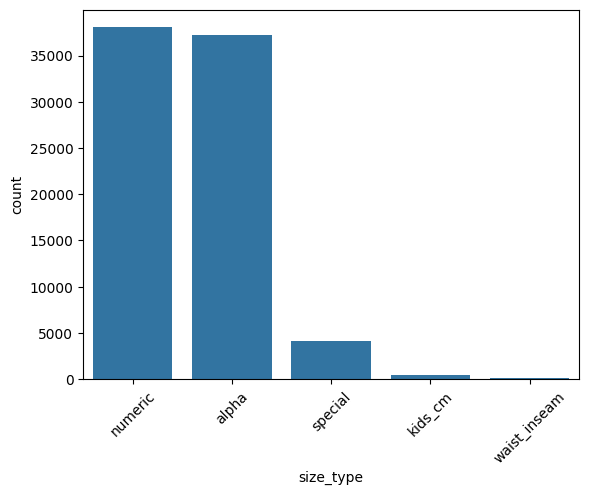

In [53]:
sns.countplot(data=model_df, x="size_type")
plt.xticks(rotation=45)
plt.show()

In [54]:
pd.crosstab(
    model_df["size_type"],
    model_df["return"],
    normalize="index"
) * 100

return,0,1
size_type,,
alpha,54.932489,45.067511
kids_cm,78.199052,21.800948
numeric,51.125824,48.874176
special,72.241045,27.758955
waist_inseam,58.441558,41.558442


In [55]:
model_df["size_value"].value_counts().head(20).reset_index()

,size_value,count
0,l,9861
1,xl,8707
2,m,8200
3,xxl,7208
4,40,6368
5,39,5384
6,38,4561
7,unsized,4132
8,42,4070
9,41,3891


In [56]:
model_df["customer_age"] = (
    (model_df["order_date"] - model_df["user_dob"]).dt.days / 365.25
).round().astype("Int64")

In [57]:
model_df[["user_dob", "order_date", "customer_age"]].head()

,user_dob,order_date,customer_age
0,1969-04-17,2016-06-22,47
1,1970-04-22,2016-06-22,46
2,1970-04-22,2016-06-22,46
3,1960-01-09,2016-06-23,56
4,NaT,2016-06-23,<NA>


In [58]:
model_df["order_month"] = model_df["order_date"].dt.month_name()

In [59]:
model_df["order_day"] = model_df["order_date"].dt.day_name()

In [60]:
model_df["is_weekend"] = (model_df["order_date"].dt.weekday >= 5).astype(int)

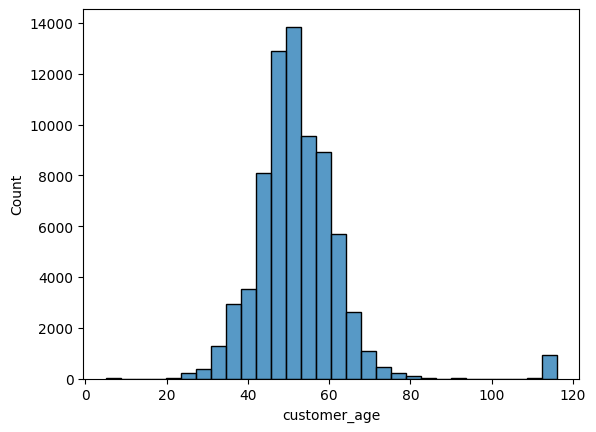

In [61]:
sns.histplot(model_df["customer_age"], bins=30)
plt.show()

<Axes: ylabel='customer_age'>

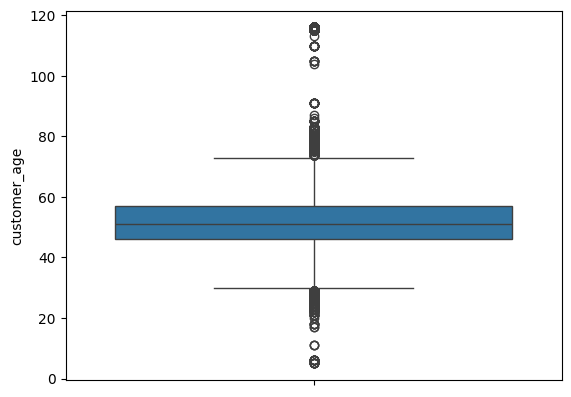

In [62]:
sns.boxplot(model_df['customer_age'])

In [63]:
Q1 = model_df["customer_age"].quantile(0.25)
Q3 = model_df["customer_age"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("lower:",lower)
print("upper:",upper)

lower: 29.5
upper: 73.5


In [64]:
age_outliers = model_df[
    (model_df["customer_age"] < lower) |
    (model_df["customer_age"] > upper)
]

age_outliers.shape

(2005, 23)

In [65]:
model_df[model_df["customer_age"] > 100][
    ["user_dob", "order_date", "customer_age"]
].shape

(966, 3)

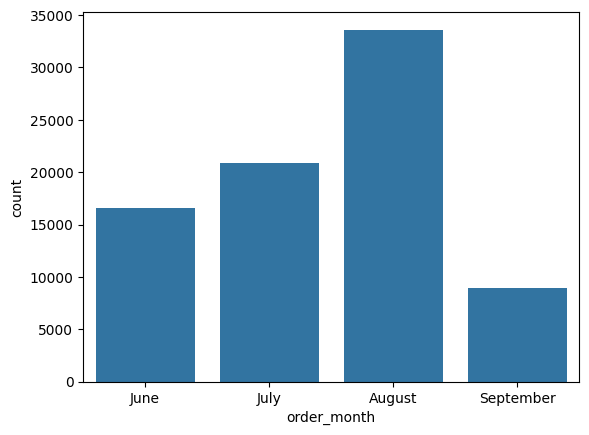

In [66]:
sns.countplot(data=model_df, x="order_month")
plt.xticks()
plt.show()

In [67]:
model_df["is_weekend"].value_counts()

is_weekend
0    58581
1    21364
Name: count, dtype: int64

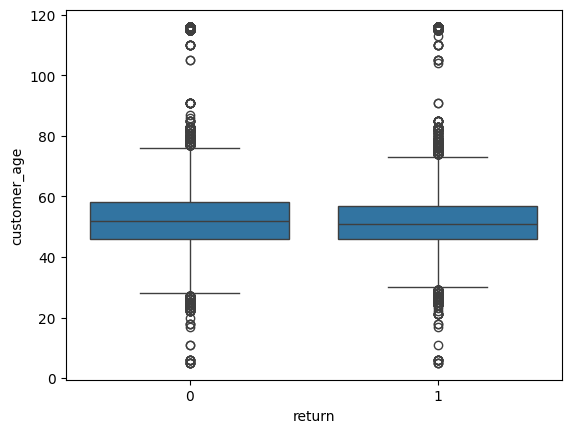

In [68]:
sns.boxplot(data=model_df, x="return", y="customer_age")
plt.show()

In [69]:
pd.crosstab(
    model_df["order_day"],
    model_df["return"],
    normalize="index"
) * 100

return,0,1
order_day,,
Friday,52.834840,47.165160
Monday,55.769367,44.230633
Saturday,53.541858,46.458142
Sunday,54.030875,45.969125
Thursday,54.933486,45.066514
Tuesday,54.670962,45.329038
Wednesday,52.914725,47.085275


In [70]:
pd.crosstab(
    model_df["is_weekend"],
    model_df["return"],
    normalize="index"
) * 100

return,0,1
is_weekend,,
0,54.271863,45.728137
1,53.782063,46.217937


# Feature Selection

In [72]:
# Replace pandas <NA> with numpy.nan
model_df["size_value"] = model_df["size_value"].replace({pd.NA: np.nan})

# Convert to object dtype
model_df["size_value"] = model_df["size_value"].astype(object)

model_df["customer_age"] = model_df["customer_age"].astype("float64")

In [73]:
model_df_1=model_df.copy()

In [74]:
model_df_1.drop(
    columns=[
        "order_item_id",
        "user_id",
        "delivery_date",
        "user_dob",
        "user_reg_date",
        "order_date",
        "item_id"
    ],
    inplace=True
)

In [75]:
list(model_df_1.columns)

['item_color',
 'brand_id',
 'item_price',
 'user_title',
 'user_state',
 'return',
 'size_type',
 'size_value',
 'waist_size',
 'inseam_size',
 'waist_size_missing',
 'inseam_size_missing',
 'customer_age',
 'order_month',
 'order_day',
 'is_weekend']

# Train-Test Split

In [77]:
X = model_df_1.drop("return", axis=1)
y = model_df_1["return"]

In [78]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Using stratify=y ensures that both the training and testing sets keep approximately the same class distribution as the original dataset.

# ML Preprocessing

In [81]:
X_train.head()

,item_color,brand_id,item_price,user_title,user_state,size_type,size_value,waist_size,inseam_size,waist_size_missing,inseam_size_missing,customer_age,order_month,order_day,is_weekend
16482,black,34,59.9,Mrs,1006,numeric,19,NaN,NaN,1,1,51.0,August,Thursday,0
841,blue,1,64.9,Mrs,1002,numeric,39,NaN,NaN,1,1,54.0,June,Monday,0
1256,blue,40,59.9,Mrs,1001,numeric,39,NaN,NaN,1,1,41.0,June,Tuesday,0
74643,olive,6,39.9,Mrs,1001,numeric,46,NaN,NaN,1,1,49.0,July,Sunday,1
43896,turquoise,42,119.9,Mrs,1001,alpha,xxl,NaN,NaN,1,1,NaN,July,Wednesday,0


In [82]:
num_cols = [
    "item_price",
    "customer_age"
]

In [83]:
waist_cols = [
    "waist_size",
    "inseam_size"
]

In [84]:
cat_cols = [
    "item_color",
    "brand_id",
    "user_title",
    "user_state",
    "order_month",
    "order_day",
    "size_type",
    "size_value",
]

In [85]:
binary_cols = [
    "is_weekend",
    "waist_size_missing",
    "inseam_size_missing"
]

In [86]:
X_train.isnull().sum()

item_color                36
brand_id                   0
item_price                 0
user_title                 0
user_state                 0
size_type                  0
size_value                63
waist_size             63893
inseam_size            63893
waist_size_missing         0
inseam_size_missing        0
customer_age            5636
order_month                0
order_day                  0
is_weekend                 0
dtype: int64

In [87]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [88]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [89]:
waist_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value=-1)),
    ("scaler", StandardScaler())
])

In [90]:
from sklearn.preprocessing import OneHotEncoder

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [91]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, num_cols),
        ("waist", waist_pipeline, waist_cols),
        ("cat", cat_pipeline, cat_cols),
        ("binary", "passthrough", binary_cols)
    ]
)

# Model Training

## Logistic Regression

In [94]:
from sklearn.linear_model import LogisticRegression

In [95]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(random_state=42))
])

In [96]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['item_price',
                                                   'customer_age']),
                                                 ('waist',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value=-1,
                                                                                 strategy='constant')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['waist_size',
                                                   'inseam_size']),
                                                 ('cat',
                                                  Pipe...ps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['item_color', 'brand_id',
                                                   'user_title', 'user_state',
                                                   'order_month', 'order_day',
                                                   'size_type', 'size_value']),
                                                 ('binary', 'passthrough',
                                                  ['is_weekend',
                                                   'waist_size_missing',
                                                   'inseam_size_missing'])])),
                ('classifier', LogisticRegression(random_state=42))])

In [97]:
lr_pred = model.predict(X_test)

In [98]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, lr_pred)
print("Accuracy:", accuracy)

Accuracy: 0.5968478328851086


In [99]:
from sklearn.metrics import classification_report

print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.61      0.72      0.66      8657
           1       0.58      0.46      0.51      7332

    accuracy                           0.60     15989
   macro avg       0.59      0.59      0.58     15989
weighted avg       0.59      0.60      0.59     15989



In [100]:
from sklearn.metrics import confusion_matrix

lr_cm = confusion_matrix(y_test, lr_pred)
print(lr_cm)

[[6205 2452]
 [3994 3338]]


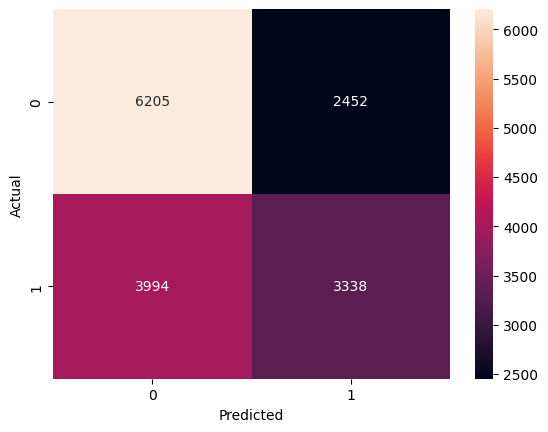

In [101]:
sns.heatmap(
    lr_cm,
    annot=True,
    fmt="d",
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [102]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:,1]

roc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc)

ROC-AUC: 0.6367331234555274


## Decision Tree

In [104]:
from sklearn.tree import DecisionTreeClassifier

In [105]:
dt_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

In [106]:
dt_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['item_price',
                                                   'customer_age']),
                                                 ('waist',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value=-1,
                                                                                 strategy='constant')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['waist_size',
                                                   'inseam_size']),
                                                 ('cat',
                                                  Pipe...('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['item_color', 'brand_id',
                                                   'user_title', 'user_state',
                                                   'order_month', 'order_day',
                                                   'size_type', 'size_value']),
                                                 ('binary', 'passthrough',
                                                  ['is_weekend',
                                                   'waist_size_missing',
                                                   'inseam_size_missing'])])),
                ('classifier', DecisionTreeClassifier(random_state=42))])

In [107]:
dt_pred = dt_model.predict(X_test)

In [108]:
dt_accuracy=accuracy_score(y_test, dt_pred)
print("Accuracy:",dt_accuracy)

Accuracy: 0.5769591594221027


In [109]:
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.61      0.61      0.61      8657
           1       0.54      0.54      0.54      7332

    accuracy                           0.58     15989
   macro avg       0.57      0.57      0.57     15989
weighted avg       0.58      0.58      0.58     15989



In [110]:
dt_cm = confusion_matrix(y_test, dt_pred)
print(dt_cm)

[[5272 3385]
 [3379 3953]]


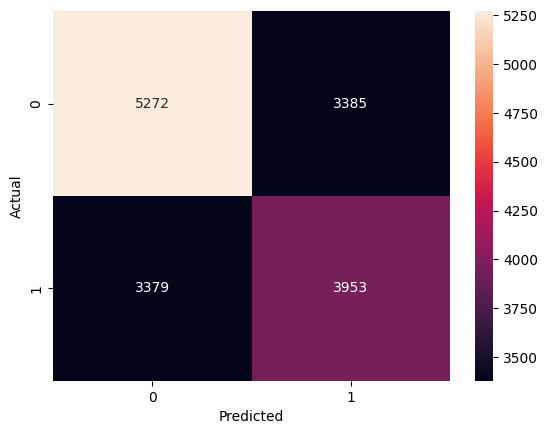

In [111]:
sns.heatmap(
    dt_cm,
    annot=True,
    fmt="d",
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [112]:
from sklearn.metrics import roc_auc_score

y_prob = dt_model.predict_proba(X_test)[:,1]

roc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc)

ROC-AUC: 0.5745527508619238


## Random Forest

#### Random Forest (Baseline)

In [115]:
from sklearn.ensemble import RandomForestClassifier

In [116]:
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=42
    ))
])

In [117]:
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['item_price',
                                                   'customer_age']),
                                                 ('waist',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value=-1,
                                                                                 strategy='constant')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['waist_size',
                                                   'inseam_size']),
                                                 ('cat',
                                                  Pipe...('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['item_color', 'brand_id',
                                                   'user_title', 'user_state',
                                                   'order_month', 'order_day',
                                                   'size_type', 'size_value']),
                                                 ('binary', 'passthrough',
                                                  ['is_weekend',
                                                   'waist_size_missing',
                                                   'inseam_size_missing'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

In [118]:
rf_pred = rf_model.predict(X_test)

In [119]:
accuracy = accuracy_score(y_test, rf_pred)
print("Accuracy:", accuracy)

Accuracy: 0.6202389142535493


In [120]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.64      0.68      0.66      8657
           1       0.59      0.54      0.57      7332

    accuracy                           0.62     15989
   macro avg       0.62      0.61      0.61     15989
weighted avg       0.62      0.62      0.62     15989



In [121]:
rf_cm = confusion_matrix(y_test, rf_pred)
print(rf_cm)

[[5929 2728]
 [3344 3988]]


In [122]:
rf_prob = rf_model.predict_proba(X_test)[:,1]

roc_rf = roc_auc_score(y_test, rf_prob)

print("ROC-AUC:", roc_rf)

ROC-AUC: 0.6656725923872914


## Comparison Table

In [124]:
results = {
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        0.5968,
        0.5770,
        0.6202
    ]
}

import pandas as pd

pd.DataFrame(results)

,Model,Accuracy
0,Logistic Regression,0.5968
1,Decision Tree,0.5770
2,Random Forest,0.6202


# Adding more features to improve accuracy

## Feature-1 (+ customer_total_orders)

In [127]:
model_df_2=model_df.copy()

In [128]:
model_df_2.columns

Index(['order_item_id', 'order_date', 'delivery_date', 'item_id', 'item_color',
       'brand_id', 'item_price', 'user_id', 'user_title', 'user_dob',
       'user_state', 'user_reg_date', 'return', 'size_type', 'size_value',
       'waist_size', 'inseam_size', 'waist_size_missing',
       'inseam_size_missing', 'customer_age', 'order_month', 'order_day',
       'is_weekend'],
      dtype='object')

In [129]:
from sklearn.model_selection import train_test_split

X = model_df_2.drop(columns="return")
y = model_df_2["return"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [130]:
customer_orders = X_train.groupby("user_id").size()

In [131]:
X_train["customer_total_orders"] = (
    X_train["user_id"]
    .map(customer_orders)
)

In [132]:
X_test["customer_total_orders"] = (
    X_test["user_id"]
    .map(customer_orders)
    .fillna(1)
)

In [133]:
X_train.drop(columns="user_id", inplace=True)
X_test.drop(columns="user_id", inplace=True)

In [134]:
num_cols = [
    "item_price",
    "customer_age",
    "customer_total_orders"
]

In [135]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [136]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, num_cols),
        ("waist", waist_pipeline, waist_cols),
        ("cat", cat_pipeline, cat_cols),
        ("binary", "passthrough", binary_cols)
    ]
)

In [137]:
rf_model_2 = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

In [138]:
rf_model_2.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['item_price', 'customer_age',
                                                   'customer_total_orders']),
                                                 ('waist',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value=-1,
                                                                                 strategy='constant')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['waist_size',
                                                   'in...
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['item_color', 'brand_id',
                                                   'user_title', 'user_state',
                                                   'order_month', 'order_day',
                                                   'size_type', 'size_value']),
                                                 ('binary', 'passthrough',
                                                  ['is_weekend',
                                                   'waist_size_missing',
                                                   'inseam_size_missing'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

In [139]:
rf_pred_2 = rf_model_2.predict(X_test)

In [140]:
accuracy = accuracy_score(y_test, rf_pred_2)

print("Accuracy:", accuracy)

Accuracy: 0.6395021577334418


In [141]:
print(classification_report(y_test, rf_pred_2))

              precision    recall  f1-score   support

           0       0.65      0.74      0.69      8657
           1       0.63      0.52      0.57      7332

    accuracy                           0.64     15989
   macro avg       0.64      0.63      0.63     15989
weighted avg       0.64      0.64      0.63     15989



In [142]:
cm_rf = confusion_matrix(y_test, rf_pred_2)

print(cm_rf)

[[6404 2253]
 [3511 3821]]


In [143]:
rf_prob = rf_model_2.predict_proba(X_test)[:, 1]

roc = roc_auc_score(y_test, rf_prob)

print("ROC-AUC:", roc)

ROC-AUC: 0.686778934970965


## Feature-2 (+ item_return_rate)

In [145]:
model_df_2.columns

Index(['order_item_id', 'order_date', 'delivery_date', 'item_id', 'item_color',
       'brand_id', 'item_price', 'user_id', 'user_title', 'user_dob',
       'user_state', 'user_reg_date', 'return', 'size_type', 'size_value',
       'waist_size', 'inseam_size', 'waist_size_missing',
       'inseam_size_missing', 'customer_age', 'order_month', 'order_day',
       'is_weekend'],
      dtype='object')

In [146]:
X = model_df_2.drop(columns="return")
y = model_df_2["return"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [147]:
train = X_train.copy()
train["return"] = y_train

In [148]:
import numpy as np

train["item_return_rate"] = np.nan

In [149]:
from sklearn.model_selection import KFold

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [150]:
global_rate = y_train.mean()

for train_idx, valid_idx in kf.split(train):

    train_fold = train.iloc[train_idx]
    valid_fold = train.iloc[valid_idx]

    item_rate = (
        train_fold
        .groupby("item_id")["return"]
        .mean()
    )

    train.loc[
        train.index[valid_idx],
        "item_return_rate"
    ] = (
        valid_fold["item_id"]
        .map(item_rate)
        .fillna(global_rate)
    )

In [151]:
train["item_return_rate"].isna().sum()

0

In [152]:
X_train["item_return_rate"] = train["item_return_rate"]

In [153]:
item_rate = (
    train
    .groupby("item_id")["return"]
    .mean()
)

In [154]:
X_test["item_return_rate"] = (
    X_test["item_id"]
    .map(item_rate)
    .fillna(global_rate)
)

In [155]:
X_train.drop(columns="item_id", inplace=True)
X_test.drop(columns="item_id", inplace=True)

In [156]:
num_cols = [
    "item_price",
    "customer_age",
    "item_return_rate"
]

In [157]:
cat_cols = [
    "item_color",
    "brand_id",
    "user_title",
    "user_state",
    "size_type",
    "size_value",
    "order_month",
    "order_day"
]

In [158]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [159]:
from sklearn.preprocessing import OneHotEncoder

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [160]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, num_cols),
        ("waist", waist_pipeline, waist_cols),
        ("cat", cat_pipeline, cat_cols),
        ("binary", "passthrough", binary_cols)
    ]
)

In [161]:
rf_model_item = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

In [162]:
rf_model_item.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['item_price', 'customer_age',
                                                   'item_return_rate']),
                                                 ('waist',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value=-1,
                                                                                 strategy='constant')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['waist_size',
                                                   'inseam_...
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['item_color', 'brand_id',
                                                   'user_title', 'user_state',
                                                   'size_type', 'size_value',
                                                   'order_month',
                                                   'order_day']),
                                                 ('binary', 'passthrough',
                                                  ['is_weekend',
                                                   'waist_size_missing',
                                                   'inseam_size_missing'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

In [163]:
rf_pred_item = rf_model_item.predict(X_test)

In [164]:
print("Accuracy:", accuracy_score(y_test, rf_pred_item))

Accuracy: 0.6287447620238914


In [165]:
print(classification_report(y_test, rf_pred_item))

              precision    recall  f1-score   support

           0       0.65      0.69      0.67      8657
           1       0.60      0.56      0.58      7332

    accuracy                           0.63     15989
   macro avg       0.63      0.62      0.62     15989
weighted avg       0.63      0.63      0.63     15989



In [166]:
rf_prob_item = rf_model_item.predict_proba(X_test)[:, 1]

roc = roc_auc_score(y_test, rf_prob_item)

print("ROC-AUC:", roc)

ROC-AUC: 0.678291405666436


## Feature-3 (+ customer_total_orders + item_return_rate)

In [168]:
X = model_df_2.drop(columns="return")
y = model_df_2["return"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [169]:
customer_orders = X_train.groupby("user_id").size()

X_train["customer_total_orders"] = (
    X_train["user_id"].map(customer_orders)
)

X_test["customer_total_orders"] = (
    X_test["user_id"]
    .map(customer_orders)
    .fillna(1)
)

In [170]:
train = X_train.copy()
train["return"] = y_train

In [171]:
import numpy as np

train["item_return_rate"] = np.nan

In [172]:
from sklearn.model_selection import KFold

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [173]:
global_rate = y_train.mean()

for train_idx, valid_idx in kf.split(train):

    train_fold = train.iloc[train_idx]
    valid_fold = train.iloc[valid_idx]

    item_rate = (
        train_fold
        .groupby("item_id")["return"]
        .mean()
    )

    train.loc[
        train.index[valid_idx],
        "item_return_rate"
    ] = (
        valid_fold["item_id"]
        .map(item_rate)
        .fillna(global_rate)
    )

In [174]:
X_train["item_return_rate"] = train["item_return_rate"]

In [175]:
item_rate = (
    train
    .groupby("item_id")["return"]
    .mean()
)

In [176]:
X_test["item_return_rate"] = (
    X_test["item_id"]
    .map(item_rate)
    .fillna(global_rate)
)

In [177]:
X_train.drop(columns=["user_id", "item_id"], inplace=True)
X_test.drop(columns=["user_id", "item_id"], inplace=True)

In [178]:
num_cols = [
    "item_price",
    "customer_age",
    "customer_total_orders",
    "item_return_rate"
]

In [179]:
waist_cols = [
    "waist_size",
    "inseam_size"
]

In [180]:
cat_cols = [
    "item_color",
    "brand_id",
    "user_title",
    "user_state",
    "size_type",
    "size_value",
    "order_month",
    "order_day"
]

In [181]:
binary_cols = [
    "waist_size_missing",
    "inseam_size_missing",
    "is_weekend"
]

In [182]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [183]:
from sklearn.preprocessing import OneHotEncoder

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [184]:
waist_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value=-1)),
    ("scaler", StandardScaler())
])

In [185]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, num_cols),
        ("waist", waist_pipeline, waist_cols),
        ("cat", cat_pipeline, cat_cols),
        ("binary", "passthrough", binary_cols)
    ]
)

In [186]:
rf_model_combined = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

In [187]:
rf_model_combined.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['item_price', 'customer_age',
                                                   'customer_total_orders',
                                                   'item_return_rate']),
                                                 ('waist',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value=-1,
                                                                                 strategy='constant')),
                                                                  ('scaler',
                                                                   StandardScaler())]...
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['item_color', 'brand_id',
                                                   'user_title', 'user_state',
                                                   'size_type', 'size_value',
                                                   'order_month',
                                                   'order_day']),
                                                 ('binary', 'passthrough',
                                                  ['waist_size_missing',
                                                   'inseam_size_missing',
                                                   'is_weekend'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

In [188]:
rf_pred_combined = rf_model_combined.predict(X_test)

In [189]:
print("Accuracy:", accuracy_score(y_test, rf_pred_combined))

Accuracy: 0.6406279317030459


In [190]:
print(classification_report(y_test, rf_pred_combined))

              precision    recall  f1-score   support

           0       0.65      0.74      0.69      8657
           1       0.63      0.53      0.57      7332

    accuracy                           0.64     15989
   macro avg       0.64      0.63      0.63     15989
weighted avg       0.64      0.64      0.64     15989



In [191]:
rf_prob = rf_model_combined.predict_proba(X_test)[:,1]

print("ROC-AUC:", roc_auc_score(y_test, rf_prob))

ROC-AUC: 0.6944154347909518


In [192]:
print(confusion_matrix(y_test, rf_pred_combined))

[[6367 2290]
 [3456 3876]]


## Feature-4 (+ customer_return_rate)

In [194]:
X = model_df_2.drop(columns="return")
y = model_df_2["return"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [195]:
train = X_train.copy()
train["return"] = y_train

In [196]:
import numpy as np

train["customer_return_rate"] = np.nan

In [197]:
from sklearn.model_selection import KFold

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [198]:
global_rate = y_train.mean()

for train_idx, valid_idx in kf.split(train):

    train_fold = train.iloc[train_idx]
    valid_fold = train.iloc[valid_idx]

    customer_rate = (
        train_fold
        .groupby("user_id")["return"]
        .mean()
    )

    train.loc[
        train.index[valid_idx],
        "customer_return_rate"
    ] = (
        valid_fold["user_id"]
        .map(customer_rate)
        .fillna(global_rate)
    )

In [199]:
train["customer_return_rate"].isna().sum()

0

In [200]:
X_train["customer_return_rate"] = train["customer_return_rate"]

In [201]:
customer_rate = (
    train
    .groupby("user_id")["return"]
    .mean()
)

In [202]:
X_test["customer_return_rate"] = (
    X_test["user_id"]
    .map(customer_rate)
    .fillna(global_rate)
)

In [203]:
X_train.drop(columns="user_id", inplace=True)
X_test.drop(columns="user_id", inplace=True)

In [204]:
num_cols = [
    "item_price",
    "customer_age",
    "customer_return_rate"
]

In [205]:
cat_cols = [
    "item_color",
    "item_id",
    "brand_id",
    "user_title",
    "user_state",
    "size_type",
    "size_value",
    "order_month",
    "order_day"
]

In [206]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [207]:
from sklearn.preprocessing import OneHotEncoder

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [208]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, num_cols),
        ("waist", waist_pipeline, waist_cols),
        ("cat", cat_pipeline, cat_cols),
        ("binary", "passthrough", binary_cols)
    ]
)

In [209]:
rf_customer_return = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

In [210]:
rf_customer_return.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['item_price', 'customer_age',
                                                   'customer_return_rate']),
                                                 ('waist',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value=-1,
                                                                                 strategy='constant')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['waist_size',
                                                   'ins...
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['item_color', 'item_id',
                                                   'brand_id', 'user_title',
                                                   'user_state', 'size_type',
                                                   'size_value', 'order_month',
                                                   'order_day']),
                                                 ('binary', 'passthrough',
                                                  ['waist_size_missing',
                                                   'inseam_size_missing',
                                                   'is_weekend'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

In [211]:
rf_pred_customer_return = rf_customer_return.predict(X_test)

In [212]:
print("Accuracy:", accuracy_score(y_test, rf_pred_customer_return))

Accuracy: 0.6612671211457878


In [213]:
print(classification_report(y_test, rf_pred_customer_return))

              precision    recall  f1-score   support

           0       0.68      0.71      0.70      8657
           1       0.64      0.60      0.62      7332

    accuracy                           0.66     15989
   macro avg       0.66      0.66      0.66     15989
weighted avg       0.66      0.66      0.66     15989



In [214]:
print(confusion_matrix(y_test, rf_pred_customer_return))

[[6175 2482]
 [2934 4398]]


In [215]:
rf_prob_customer_return = rf_customer_return.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, rf_prob_customer_return))

ROC-AUC: 0.7201832778862436


## Feature-5 Final model (+customer_total_order+customer_return_rate)

In [217]:
from sklearn.model_selection import train_test_split

X = model_df_2.drop(columns="return")
y = model_df_2["return"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [218]:
customer_orders = X_train.groupby("user_id").size()

X_train["customer_total_orders"] = (
    X_train["user_id"].map(customer_orders)
)

X_test["customer_total_orders"] = (
    X_test["user_id"]
    .map(customer_orders)
    .fillna(1)
)

In [219]:
train = X_train.copy()
train["return"] = y_train

In [220]:
import numpy as np

train["customer_return_rate"] = np.nan

In [221]:
from sklearn.model_selection import KFold

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [222]:
global_rate = y_train.mean()

for train_idx, valid_idx in kf.split(train):

    train_fold = train.iloc[train_idx]
    valid_fold = train.iloc[valid_idx]

    customer_rate = (
        train_fold
        .groupby("user_id")["return"]
        .mean()
    )

    train.loc[
        train.index[valid_idx],
        "customer_return_rate"
    ] = (
        valid_fold["user_id"]
        .map(customer_rate)
        .fillna(global_rate)
    )

In [223]:
X_train["customer_return_rate"] = train["customer_return_rate"]

In [224]:
customer_rate = (
    train
    .groupby("user_id")["return"]
    .mean()
)

X_test["customer_return_rate"] = (
    X_test["user_id"]
    .map(customer_rate)
    .fillna(global_rate)
)

In [225]:
X_train.drop(columns="user_id", inplace=True)
X_test.drop(columns="user_id", inplace=True)

In [226]:
num_cols = [
    "item_price",
    "customer_age",
    "customer_total_orders",
    "customer_return_rate"
]

In [227]:
waist_cols = [
    "waist_size",
    "inseam_size"
]

In [228]:
cat_cols = [
    "item_color",
    "item_id",
    "brand_id",
    "user_title",
    "user_state",
    "size_type",
    "size_value",
    "order_month",
    "order_day"
]

In [229]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, num_cols),
        ("waist", waist_pipeline, waist_cols),
        ("cat", cat_pipeline, cat_cols),
        ("binary", "passthrough", binary_cols)
    ]
)

In [230]:
rf_final = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

In [231]:
rf_final.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['item_price', 'customer_age',
                                                   'customer_total_orders',
                                                   'customer_return_rate']),
                                                 ('waist',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value=-1,
                                                                                 strategy='constant')),
                                                                  ('scaler',
                                                                   StandardScaler...
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['item_color', 'item_id',
                                                   'brand_id', 'user_title',
                                                   'user_state', 'size_type',
                                                   'size_value', 'order_month',
                                                   'order_day']),
                                                 ('binary', 'passthrough',
                                                  ['waist_size_missing',
                                                   'inseam_size_missing',
                                                   'is_weekend'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

In [232]:
rf_pred_final = rf_final.predict(X_test)

In [233]:
print("Accuracy:", accuracy_score(y_test, rf_pred_final))

Accuracy: 0.6630183250985052


In [234]:
print(classification_report(y_test, rf_pred_final))

              precision    recall  f1-score   support

           0       0.67      0.74      0.70      8657
           1       0.65      0.58      0.61      7332

    accuracy                           0.66     15989
   macro avg       0.66      0.66      0.66     15989
weighted avg       0.66      0.66      0.66     15989



In [235]:
print(confusion_matrix(y_test, rf_pred_final))

[[6367 2290]
 [3098 4234]]


In [236]:
rf_prob_final = rf_final.predict_proba(X_test)[:,1]

print("ROC-AUC:", roc_auc_score(y_test, rf_prob_final))

ROC-AUC: 0.7253726474846267


# Comparison table

In [238]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest (Baseline)",
        "Random Forest (+ customer_total_orders)",
        "Random Forest (+ item_return_rate)",
        "Random Forest (+ customer_total_orders + item_return_rate)",
        "Random Forest (+ customer_return_rate)",
        "Random Forest (Final model)"
    ],

    "Accuracy": [
        0.5968,
        0.5770,
        0.6202,
        0.6406,
        0.6287,
        0.6406,
        0.6613,
        0.6630
    ],

    "ROC-AUC": [
        0.6367,
        0.5745,
        0.6367,
        0.6868,
        0.6783,
        0.6944,
        0.7202,
        0.7254,
    ],

    "Precision (Return)": [
        0.58,
        0.54,
        0.59,
        0.63,
        0.60,
        0.63,
        0.64,
        0.65,
    ],

    "Recall (Return)": [
        0.46,
        0.54,
        0.54,
        0.52,
        0.56,
        0.53,
        0.60,
        0.58,
    ],

    "F1-Score (Return)": [
        0.51,
        0.54,
        0.57,
        0.57,
        0.58,
        0.57,
        0.62,
        0.61
    ]
})

comparison

,Model,Accuracy,ROC-AUC,Precision (Return),Recall (Return),F1-Score (Return)
0,Logistic Regression,0.5968,0.6367,0.58,0.46,0.51
1,Decision Tree,0.5770,0.5745,0.54,0.54,0.54
2,Random Forest (Baseline),0.6202,0.6367,0.59,0.54,0.57
3,Random Forest (+ customer_total_orders),0.6406,0.6868,0.63,0.52,0.57
4,Random Forest (+ item_return_rate),0.6287,0.6783,0.60,0.56,0.58
5,Random Forest (+ customer_total_orders + item_...,0.6406,0.6944,0.63,0.53,0.57
6,Random Forest (+ customer_return_rate),0.6613,0.7202,0.64,0.60,0.62
7,Random Forest (Final model),0.6630,0.7254,0.65,0.58,0.61


# Advanced model

## LGBM model

In [241]:
!pip install lightgbm

In [242]:
from lightgbm import LGBMClassifier

In [243]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, num_cols),
        ("waist", waist_pipeline, waist_cols),
        ("cat", cat_pipeline, cat_cols),
        ("binary", "passthrough", binary_cols)
    ]
)

In [244]:
from lightgbm import LGBMClassifier

lgbm_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LGBMClassifier(
        random_state=42
    ))
])

In [245]:
lgbm_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 29330, number of negative: 34626
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004705 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2656
[LightGBM] [Info] Number of data points in the train set: 63956, number of used features: 1056
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.458597 -> initscore=-0.165994
[LightGBM] [Info] Start training from score -0.165994


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['item_price', 'customer_age',
                                                   'customer_total_orders',
                                                   'customer_return_rate']),
                                                 ('waist',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value=-1,
                                                                                 strategy='constant')),
                                                                  ('scaler',
                                                                   StandardScaler...
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['item_color', 'item_id',
                                                   'brand_id', 'user_title',
                                                   'user_state', 'size_type',
                                                   'size_value', 'order_month',
                                                   'order_day']),
                                                 ('binary', 'passthrough',
                                                  ['waist_size_missing',
                                                   'inseam_size_missing',
                                                   'is_weekend'])])),
                ('classifier', LGBMClassifier(random_state=42))])

In [246]:
lgbm_pred = lgbm_model.predict(X_test)

In [247]:
print("Accuracy:", accuracy_score(y_test, lgbm_pred))

Accuracy: 0.6649571580461567


In [248]:
print(classification_report(y_test, lgbm_pred))

              precision    recall  f1-score   support

           0       0.68      0.71      0.70      8657
           1       0.64      0.61      0.63      7332

    accuracy                           0.66     15989
   macro avg       0.66      0.66      0.66     15989
weighted avg       0.66      0.66      0.66     15989



In [249]:
print(confusion_matrix(y_test, lgbm_pred))

[[6157 2500]
 [2857 4475]]


In [250]:
lgbm_prob = lgbm_model.predict_proba(X_test)[:,1]

print("ROC-AUC:", roc_auc_score(y_test, lgbm_prob))

ROC-AUC: 0.7281400707486843


## Catboost model

In [265]:
!pip install catboost

In [266]:
from catboost import CatBoostClassifier

In [267]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, num_cols),
        ("waist", waist_pipeline, waist_cols),
        ("cat", cat_pipeline, cat_cols),
        ("binary", "passthrough", binary_cols)
    ]
)

In [268]:
cat_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", CatBoostClassifier(
        random_state=42,
        verbose=0
    ))
])

In [269]:
cat_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['item_price', 'customer_age',
                                                   'customer_total_orders',
                                                   'customer_return_rate']),
                                                 ('waist',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value=-1,
                                                                                 strategy='constant')),
                                                                  ('scaler',
                                                                   StandardScaler...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['item_color', 'item_id',
                                                   'brand_id', 'user_title',
                                                   'user_state', 'size_type',
                                                   'size_value', 'order_month',
                                                   'order_day']),
                                                 ('binary', 'passthrough',
                                                  ['waist_size_missing',
                                                   'inseam_size_missing',
                                                   'is_weekend'])])),
                ('classifier', CatBoostClassifier(random_state=42, verbose=0))])

In [270]:
cat_pred = cat_model.predict(X_test)

In [271]:
print("Accuracy:", accuracy_score(y_test, cat_pred))

Accuracy: 0.6685846519482144


In [272]:
print(classification_report(y_test, cat_pred))

              precision    recall  f1-score   support

           0       0.68      0.73      0.70      8657
           1       0.65      0.60      0.62      7332

    accuracy                           0.67     15989
   macro avg       0.67      0.66      0.66     15989
weighted avg       0.67      0.67      0.67     15989



In [273]:
print(confusion_matrix(y_test, cat_pred))

[[6317 2340]
 [2959 4373]]


In [274]:
cat_prob = cat_model.predict_proba(X_test)[:,1]

print("ROC-AUC:", roc_auc_score(y_test, cat_prob))

ROC-AUC: 0.731157221755778


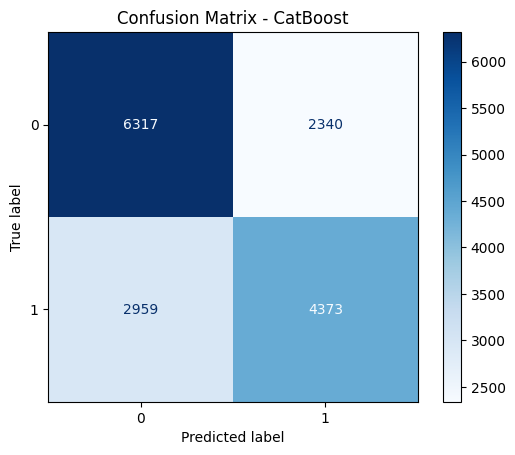

In [527]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    cat_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix - CatBoost")
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

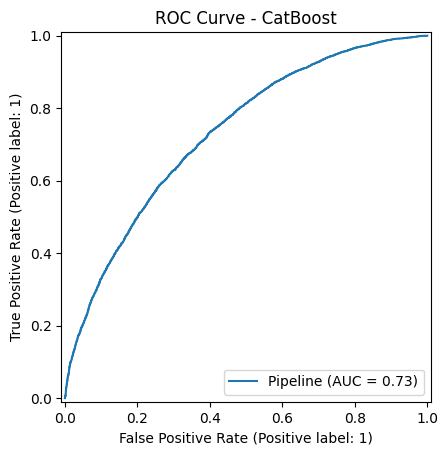

In [516]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_estimator(
    cat_model,
    X_test,
    y_test
)

plt.title("ROC Curve - CatBoost")
plt.savefig("roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [518]:
import pandas as pd
import matplotlib.pyplot as plt

# Get trained CatBoost model
model = cat_model.named_steps["classifier"]

# Get transformed feature names
feature_names = cat_model.named_steps["preprocessor"].get_feature_names_out()

# Feature importance
importance = model.feature_importances_

feature_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values("Importance", ascending=False)

feature_imp.head(15)

,Feature,Importance
3,num__customer_return_rate,21.403295
0,num__item_price,11.599924
2,num__customer_total_orders,8.609857
1,num__customer_age,5.380383
2173,cat__order_month_June,1.028214
2171,cat__order_month_August,0.959812
2097,cat__size_type_alpha,0.954541
2100,cat__size_type_special,0.795246
1956,cat__brand_id_11,0.776418
2181,cat__order_day_Wednesday,0.751529


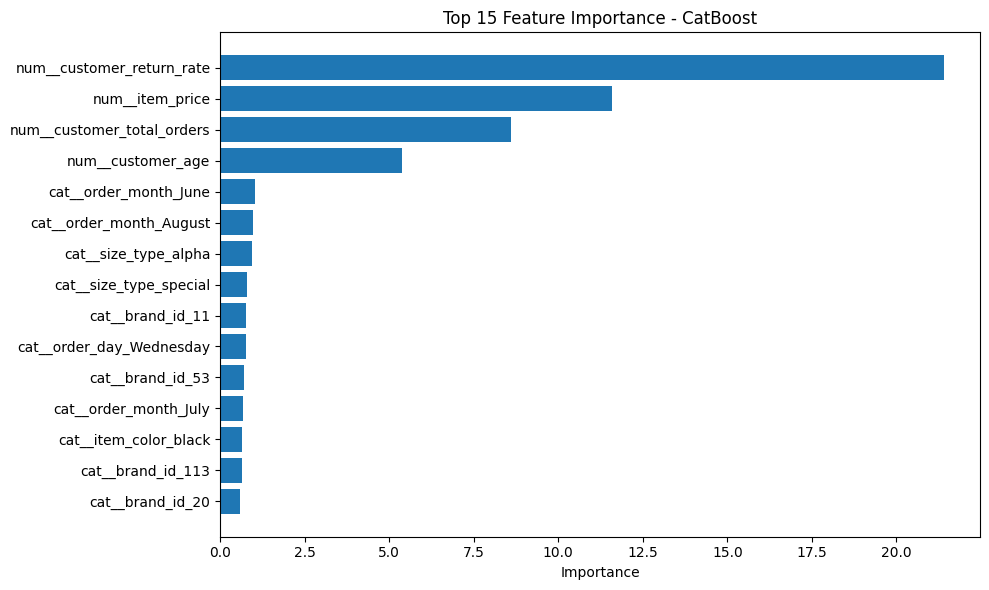

In [520]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_imp["Feature"][:15][::-1],
    feature_imp["Importance"][:15][::-1]
)

plt.xlabel("Importance")
plt.title("Top 15 Feature Importance - CatBoost")

plt.tight_layout()

plt.savefig("feature_importance.png", dpi=300)

plt.show()

# Comparison table

In [276]:
import pandas as pd

comparison = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest (Baseline)",
        "Random Forest (+ customer_total_orders)",
        "Random Forest (+ item_return_rate)",
        "Random Forest (+ customer_total_orders + item_return_rate)",
        "Random Forest (+ customer_return_rate)",
        "Random Forest (+ customer_total_orders + customer_return_rate)",
        "LightGBM (Default)",
        "LightGBM (Tuned)",
        "CatBoost (Default)"
    ],

    "Accuracy": [
        0.5968,
        0.5770,
        0.6202,
        0.6406,
        0.6287,
        0.6406,
        0.6613,
        0.6630,
        0.6650,
        0.6645,
        0.6686
    ],

    "ROC-AUC": [
        0.6367,
        0.5745,
        0.6367,
        0.6868,
        0.6783,
        0.6944,
        0.7202,
        0.7254,
        0.7281,
        0.7286,
        0.7312
    ],

    "Precision (Return)": [
        0.58,
        0.54,
        0.59,
        0.63,
        0.60,
        0.63,
        0.64,
        0.65,
        0.64,
        0.64,
        0.65
    ],

    "Recall (Return)": [
        0.46,
        0.54,
        0.54,
        0.52,
        0.56,
        0.53,
        0.60,
        0.58,
        0.61,
        0.61,
        0.60
    ],

    "F1-Score (Return)": [
        0.51,
        0.54,
        0.57,
        0.57,
        0.58,
        0.57,
        0.62,
        0.61,
        0.63,
        0.63,
        0.62
    ]

})

comparison.style.format({
    "Accuracy": "{:.2%}",
    "ROC-AUC": "{:.4f}",
    "Precision (Return)": "{:.2f}",
    "Recall (Return)": "{:.2f}",
    "F1-Score (Return)": "{:.2f}"
})

,Model,Accuracy,ROC-AUC,Precision (Return),Recall (Return),F1-Score (Return)
0,Logistic Regression,59.68%,0.6367,0.58,0.46,0.51
1,Decision Tree,57.70%,0.5745,0.54,0.54,0.54
2,Random Forest (Baseline),62.02%,0.6367,0.59,0.54,0.57
3,Random Forest (+ customer_total_orders),64.06%,0.6868,0.63,0.52,0.57
4,Random Forest (+ item_return_rate),62.87%,0.6783,0.60,0.56,0.58
5,Random Forest (+ customer_total_orders + item_return_rate),64.06%,0.6944,0.63,0.53,0.57
6,Random Forest (+ customer_return_rate),66.13%,0.7202,0.64,0.60,0.62
7,Random Forest (+ customer_total_orders + customer_return_rate),66.30%,0.7254,0.65,0.58,0.61
8,LightGBM (Default),66.50%,0.7281,0.64,0.61,0.63
9,LightGBM (Tuned),66.45%,0.7286,0.64,0.61,0.63


# Saving best model

In [524]:
import joblib

final_model = cat_model

joblib.dump(final_model, "ecommerce_order_return_prediction_model_v1.pkl")

['ecommerce_order_return_prediction_model_v1.pkl']

# Model testing

## Predicting on X_test

In [529]:
import joblib

loaded_model = joblib.load("ecommerce_order_return_prediction_model_v1.pkl")

In [531]:
loaded_pred = loaded_model.predict(X_test)

In [533]:
print("Accuracy:", accuracy_score(y_test, loaded_pred))

Accuracy: 0.6685846519482144


In [535]:
original_pred = cat_model.predict(X_test)

print((original_pred == loaded_pred).all())

True


In [539]:
sample = X_test.iloc[[0]]

prediction = loaded_model.predict(sample)
probability = loaded_model.predict_proba(sample)

print("Prediction:", prediction[0])
print("Probability:", probability)
print("Actual:", y_test.iloc[0])

Prediction: 0
Probability: [[0.94651489 0.05348511]]
Actual: 0


In [541]:
result = X_test.iloc[:10].copy()

result["Actual"] = y_test.iloc[:10].values
result["Predicted"] = loaded_model.predict(X_test.iloc[:10])

result

,order_item_id,order_date,delivery_date,item_id,item_color,brand_id,item_price,user_title,user_dob,user_state,...,waist_size_missing,inseam_size_missing,customer_age,order_month,order_day,is_weekend,customer_total_orders,customer_return_rate,Actual,Predicted
6530,65374,2016-08-12,2016-08-14,1436,pallid,111,8.95,Mrs,1968-11-03,1010,...,1,1,48.0,August,Friday,0,3.0,0.000000,0,0
78629,86295,2016-08-29,2016-08-30,1897,petrol,31,79.90,Mrs,1956-02-19,1008,...,1,1,61.0,August,Monday,0,7.0,0.428571,0,1
47672,76246,2016-08-21,2016-08-23,1607,stained,29,59.90,Mrs,NaT,1011,...,1,1,NaN,August,Sunday,1,2.0,0.500000,1,1
33039,30914,2016-07-08,2016-07-17,215,denim,28,59.90,Mrs,1972-02-09,1008,...,1,1,44.0,July,Friday,0,1.0,0.458597,0,0
62254,21740,2016-07-01,2016-07-03,151,brown,53,24.90,Mrs,1972-11-13,1011,...,1,1,44.0,July,Friday,0,8.0,0.750000,1,1
72723,27101,2016-07-03,2016-07-05,231,green,24,49.90,Mrs,NaT,1002,...,1,1,NaN,July,Sunday,1,1.0,0.000000,1,0
44291,42539,2016-07-25,2016-07-26,1404,mahagoni,3,16.90,Mrs,1966-01-14,1001,...,1,1,51.0,July,Monday,0,5.0,0.800000,1,0
17429,74653,2016-08-19,2016-08-22,396,grey,21,79.95,Mrs,1969-07-06,1015,...,1,1,47.0,August,Friday,0,20.0,0.700000,1,1
8439,84493,2016-08-28,NaT,73,red,35,79.90,Mrs,1970-07-03,1004,...,1,1,46.0,August,Sunday,1,53.0,0.433962,0,1
2471,24883,2016-07-03,2016-07-04,1332,red,69,44.90,Mrs,1966-11-22,1008,...,1,1,50.0,July,Sunday,1,14.0,0.428571,1,0


In [543]:
loaded_pred = loaded_model.predict(X_test)

correct = (loaded_pred == y_test).sum()
wrong = (loaded_pred != y_test).sum()

print("Correct Predictions :", correct)
print("Wrong Predictions   :", wrong)
print("Total Predictions   :", len(y_test))
print("Accuracy            :", accuracy_score(y_test, loaded_pred))

Correct Predictions : 10690
Wrong Predictions   : 5299
Total Predictions   : 15989
Accuracy            : 0.6685846519482144


## Predicting on new data

In [551]:
import pandas as pd
import numpy as np

new_order = pd.DataFrame({

    "order_item_id":[999999],
    "order_date":["2026-07-15"],
    "delivery_date":["2026-07-18"],

    "item_id":[1500],
    "item_color":["black"],
    "brand_id":[25],
    "item_price":[2999],

    "user_title":["Mrs"],
    "user_dob":["1998-05-10"],
    "user_state":[1010],
    "user_reg_date":["2023-01-01"],

    "size_type":["alpha"],
    "size_value":["M"],

    "waist_size":[np.nan],
    "inseam_size":[np.nan],

    "waist_size_missing":[1],
    "inseam_size_missing":[1],

    "customer_age":[28],

    "order_month":["July"],
    "order_day":["Tuesday"],
    "is_weekend":[0],

    "customer_total_orders":[8],
    "customer_return_rate":[0.60]

})

In [555]:
prediction = loaded_model.predict(new_order)
probability = loaded_model.predict_proba(new_order)

if prediction[0] == 1:
    print("Prediction : Returned")
else:
    print("Prediction : Not Returned")

print(f"Return Probability     : {probability[0][1]:.2%}")
print(f"Not Return Probability : {probability[0][0]:.2%}")

Prediction : Returned
Return Probability     : 55.71%
Not Return Probability : 44.29%


In [557]:
new_order["customer_return_rate"] = 0.10

In [559]:
prediction = loaded_model.predict(new_order)
probability = loaded_model.predict_proba(new_order)

if prediction[0] == 1:
    print("Prediction : Returned")
else:
    print("Prediction : Not Returned")

print(f"Return Probability     : {probability[0][1]:.2%}")
print(f"Not Return Probability : {probability[0][0]:.2%}")

Prediction : Not Returned
Return Probability     : 16.00%
Not Return Probability : 84.00%


In [561]:
new_order["customer_return_rate"] = 0.90

In [563]:
prediction = loaded_model.predict(new_order)
probability = loaded_model.predict_proba(new_order)

if prediction[0] == 1:
    print("Prediction : Returned")
else:
    print("Prediction : Not Returned")

print(f"Return Probability     : {probability[0][1]:.2%}")
print(f"Not Return Probability : {probability[0][0]:.2%}")

Prediction : Returned
Return Probability     : 58.92%
Not Return Probability : 41.08%


In [565]:
new_order["item_price"] = 10000

In [567]:
prediction = loaded_model.predict(new_order)
probability = loaded_model.predict_proba(new_order)

if prediction[0] == 1:
    print("Prediction : Returned")
else:
    print("Prediction : Not Returned")

print(f"Return Probability     : {probability[0][1]:.2%}")
print(f"Not Return Probability : {probability[0][0]:.2%}")

Prediction : Returned
Return Probability     : 58.92%
Not Return Probability : 41.08%


In [569]:
new_order["customer_total_orders"] = 1

In [571]:
prediction = loaded_model.predict(new_order)
probability = loaded_model.predict_proba(new_order)

if prediction[0] == 1:
    print("Prediction : Returned")
else:
    print("Prediction : Not Returned")

print(f"Return Probability     : {probability[0][1]:.2%}")
print(f"Not Return Probability : {probability[0][0]:.2%}")

Prediction : Not Returned
Return Probability     : 38.74%
Not Return Probability : 61.26%
